# PART D – Boosting Algorithms

In [2]:
import pandas as pd

df = pd.read_excel("Smart_Outcome_Predictor_Dataset_5200.xlsx")

print(df.columns.tolist())
print("\n")
print(df.dtypes)

['student_id', 'age', 'country_region', 'device_type', 'education_background', 'course_level', 'course_category', 'course_start_date', 'week_of_year', 'sessions', 'time_spent_hours', 'videos_watched', 'quiz_attempts', 'assignments_submitted', 'forum_posts', 'avg_quiz_score', 'attendance_rate', 'completion_status', 'final_score']


student_id                        int64
age                               int64
country_region                   object
device_type                      object
education_background             object
course_level                     object
course_category                  object
course_start_date        datetime64[ns]
week_of_year                      int64
sessions                          int64
time_spent_hours                float64
videos_watched                    int64
quiz_attempts                     int64
assignments_submitted             int64
forum_posts                       int64
avg_quiz_score                  float64
attendance_rate            

In [3]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

df = pd.read_excel("Smart_Outcome_Predictor_Dataset_5200.xlsx")

In [4]:
df['course_start_date'] = pd.to_datetime(
    df['course_start_date']
)

df['course_year'] = df['course_start_date'].dt.year

df['course_month'] = df['course_start_date'].dt.month

df['course_day'] = df['course_start_date'].dt.day

df.drop(
    'course_start_date',
    axis=1,
    inplace=True
)

In [5]:
cat_cols = [
    'country_region',
    'device_type',
    'education_background',
    'course_level',
    'course_category'
]

for col in cat_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(
        df[col].astype(str)
    )

In [6]:
X_cls = df.drop(
    ['completion_status', 'final_score'],
    axis=1
)

y_cls = df['completion_status']

In [7]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls,
    y_cls,
    test_size=0.20,
    random_state=42,
    stratify=y_cls
)

print(X_train_cls.shape)
print(X_test_cls.shape)

(4160, 19)
(1040, 19)


In [8]:
X_reg = df.drop(
    ['completion_status', 'final_score'],
    axis=1
)

y_reg = df['final_score']

In [9]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print(X_train_reg.shape)
print(X_test_reg.shape)

(4160, 19)
(1040, 19)


In [10]:
print(type(X_train_cls))
print(type(y_train_cls))

print(type(X_train_reg))
print(type(y_train_reg))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.series.Series'>


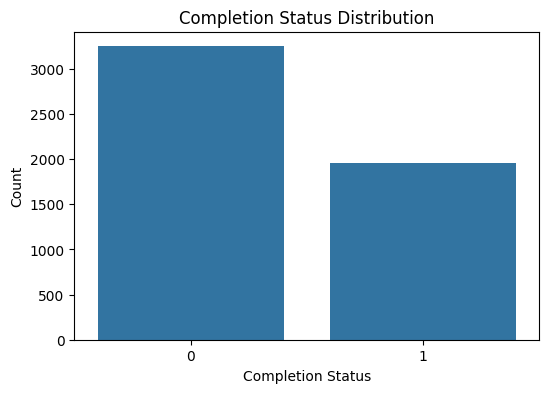

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))

sns.countplot(
    x='completion_status',
    data=df
)

plt.title("Completion Status Distribution")
plt.xlabel("Completion Status")
plt.ylabel("Count")

plt.show()

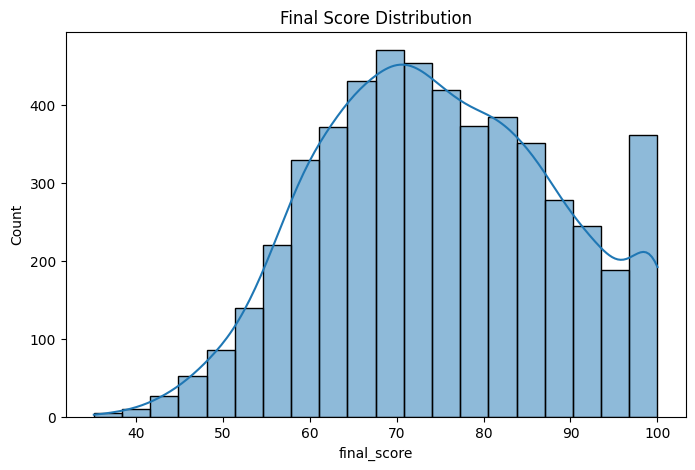

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['final_score'],
    bins=20,
    kde=True
)

plt.title("Final Score Distribution")

plt.show()

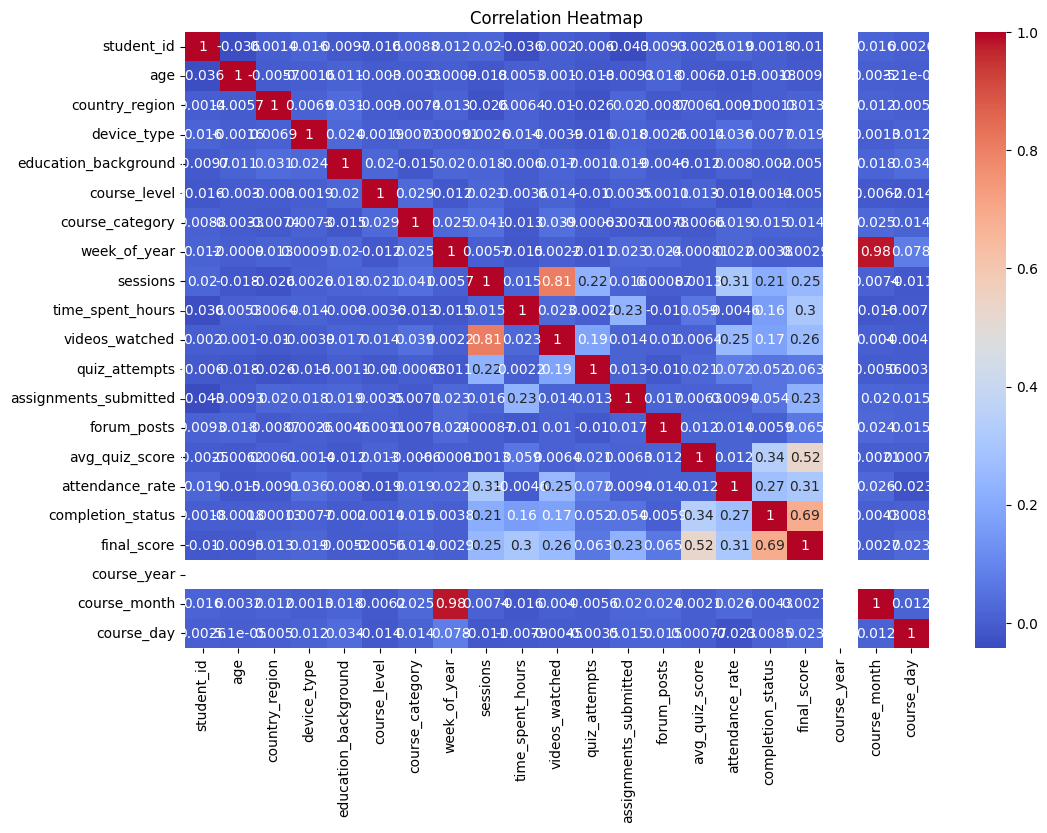

In [17]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

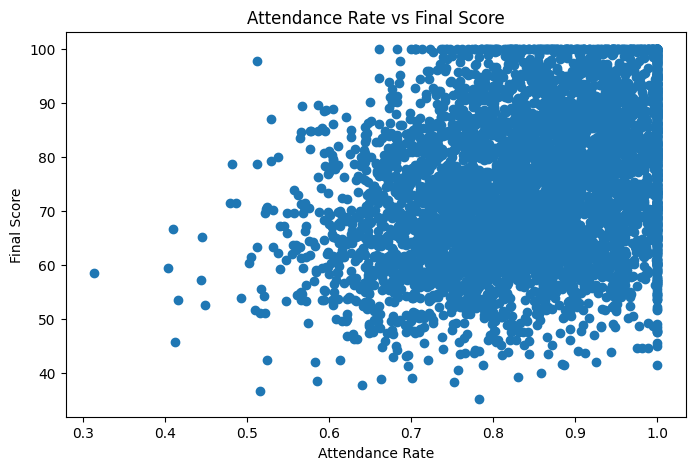

In [18]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['attendance_rate'],
    df['final_score']
)

plt.xlabel("Attendance Rate")
plt.ylabel("Final Score")

plt.title("Attendance Rate vs Final Score")

plt.show()

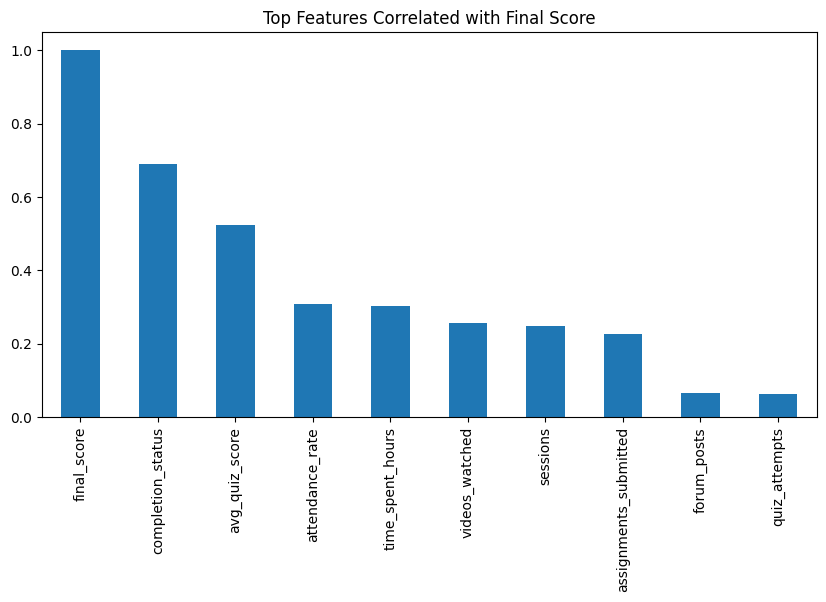

In [19]:
corr = df.corr(numeric_only=True)['final_score']

corr = corr.sort_values(
    ascending=False
).head(10)

corr.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Top Features Correlated with Final Score")

plt.show()

## Part D Conclusion (Boosting Algorithms)

Part D focused on implementing **AdaBoost** and **Gradient Boosting** algorithms for both classification and regression tasks on the Smart Outcome Predictor dataset.

### Key Observations:

* AdaBoost improved model performance by giving more importance to previously misclassified observations.
* Gradient Boosting further enhanced prediction accuracy by sequentially minimizing residual errors.
* Both boosting techniques performed better than a single Decision Tree model.
* For classification, the models achieved higher accuracy and better class prediction capability.
* For regression, the models reduced prediction errors (MAE and RMSE) and improved the R² score.
* Feature importance analysis showed that factors such as attendance rate, average quiz score, time spent on learning, and assignments submitted had a significant impact on student outcomes.

### Comparison:

* **AdaBoost** is simpler and faster but may be sensitive to noisy data.
* **Gradient Boosting** generally provides higher accuracy and better generalization by optimizing errors at each stage.

### Overall Conclusion:

Boosting algorithms significantly improved the predictive performance of the Smart Outcome Predictor system. Among the implemented methods, **Gradient Boosting demonstrated the best overall performance**, making it the preferred model for accurately predicting course completion status and final student scores. These ensemble techniques effectively reduced bias, increased accuracy, and produced more reliable predictions compared to traditional machine learning models.
